# SegNet + CycleGAN Kombi-Demo

Zieht 5 Zufallsbilder aus einem Eingabe-Ordner, lädt SegNet und CycleGAN und zeigt pro Bild Eingabe, Segmentierungsmaske und GAN-Ausgabe nebeneinander. Die Ergebnisse werden nur visualisiert (keine Dateien werden gespeichert). Beide Ausgaben werden auf das Seitenverhältnis des Eingangs zurückskaliert (keine feste 16:9-Streckung).


In [4]:
from pathlib import Path
import os, random, torch
from PIL import Image
from matplotlib import pyplot as plt

os.chdir("/srv/store/docker-users/thesis/khajuria/day2night")
print("Working dir:", os.getcwd())

# Pfade/Parameter anpassen
INPUT_DIR = Path("data/Straßen Bilder/test")
NUM_SAMPLES = 5
DIRECTION = "day2night"  # "night2day" für umgekehrtes Mapping

SEG_CONFIG = "configs/seg.yaml"
SEG_CHECKPOINT = "experiments/seg_20251204_174637/segnet_full.pth"  # None => neuestes experiments/seg_*/segnet_full.pth
CYC_CONFIG = "configs/cyclegan.yaml"
CYC_CHECKPOINT = None   # None => neuestes experiments/<exp_name>_*/epoch_*.pt
SEED = 0

random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Working dir: /srv/store/docker-users/thesis/khajuria/day2night


In [5]:
from src.utils.common import load_cfg
from src.apply_segnet import (
    build_inference_transform as build_seg_transform,
    resolve_checkpoint,
    load_segnet,
    gather_image_paths as gather_seg_paths,
    make_palette,
    make_class_names,
    tensor_to_mask,
    colorize_mask,
)
from src.apply_cyclegan import (
    build_inference_transform as build_cyc_transform,
    build_generator,
    find_checkpoint,
    tensor_to_pil,
    gather_image_paths as gather_gan_paths,
)

def load_state_dict(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")

seg_cfg = load_cfg(SEG_CONFIG)
cyc_cfg = load_cfg(CYC_CONFIG)

seg_ckpt = resolve_checkpoint(
    SEG_CHECKPOINT,
    experiments_root=seg_cfg.get("logging", {}).get("out_dir", "experiments"),
)
cyc_ckpt = find_checkpoint(CYC_CHECKPOINT, cyc_cfg)
print("SegNet checkpoint:", seg_ckpt)
print("CycleGAN checkpoint:", cyc_ckpt)

seg_transform = build_seg_transform(seg_cfg)
seg_model = load_segnet(seg_ckpt, device=device, cfg=seg_cfg)
palette = make_palette(seg_model.decoder.head[1].weight.shape[0])
class_names = make_class_names(len(palette))

gan_transform = build_cyc_transform(cyc_cfg)
generator = build_generator(cyc_cfg, device, DIRECTION)
state = load_state_dict(cyc_ckpt)
state_key = "G" if DIRECTION == "day2night" else "F"
generator.load_state_dict(state[state_key])
generator.eval()

brightness_gain = float(cyc_cfg.get("inference", {}).get("brightness_gain", 1.0))
output_gamma = float(cyc_cfg.get("inference", {}).get("output_gamma", 1.0))


SegNet checkpoint: experiments/seg_20251204_174637/segnet_full.pth
CycleGAN checkpoint: experiments/cyclegan_day2night_20251215_013246/epoch_0200.pt
Loading checkpoint: experiments/seg_20251204_174637/segnet_full.pth


/srv/store/docker-users/thesis/khajuria/day2night/src/apply_segnet.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint, map_location="cpu")


Building day2night generator | encoder: experiments/seg_20251204_174637/encoder_GE.pth | freeze=True


Zeige 5 zufällige Bilder aus data/Straßen Bilder/test


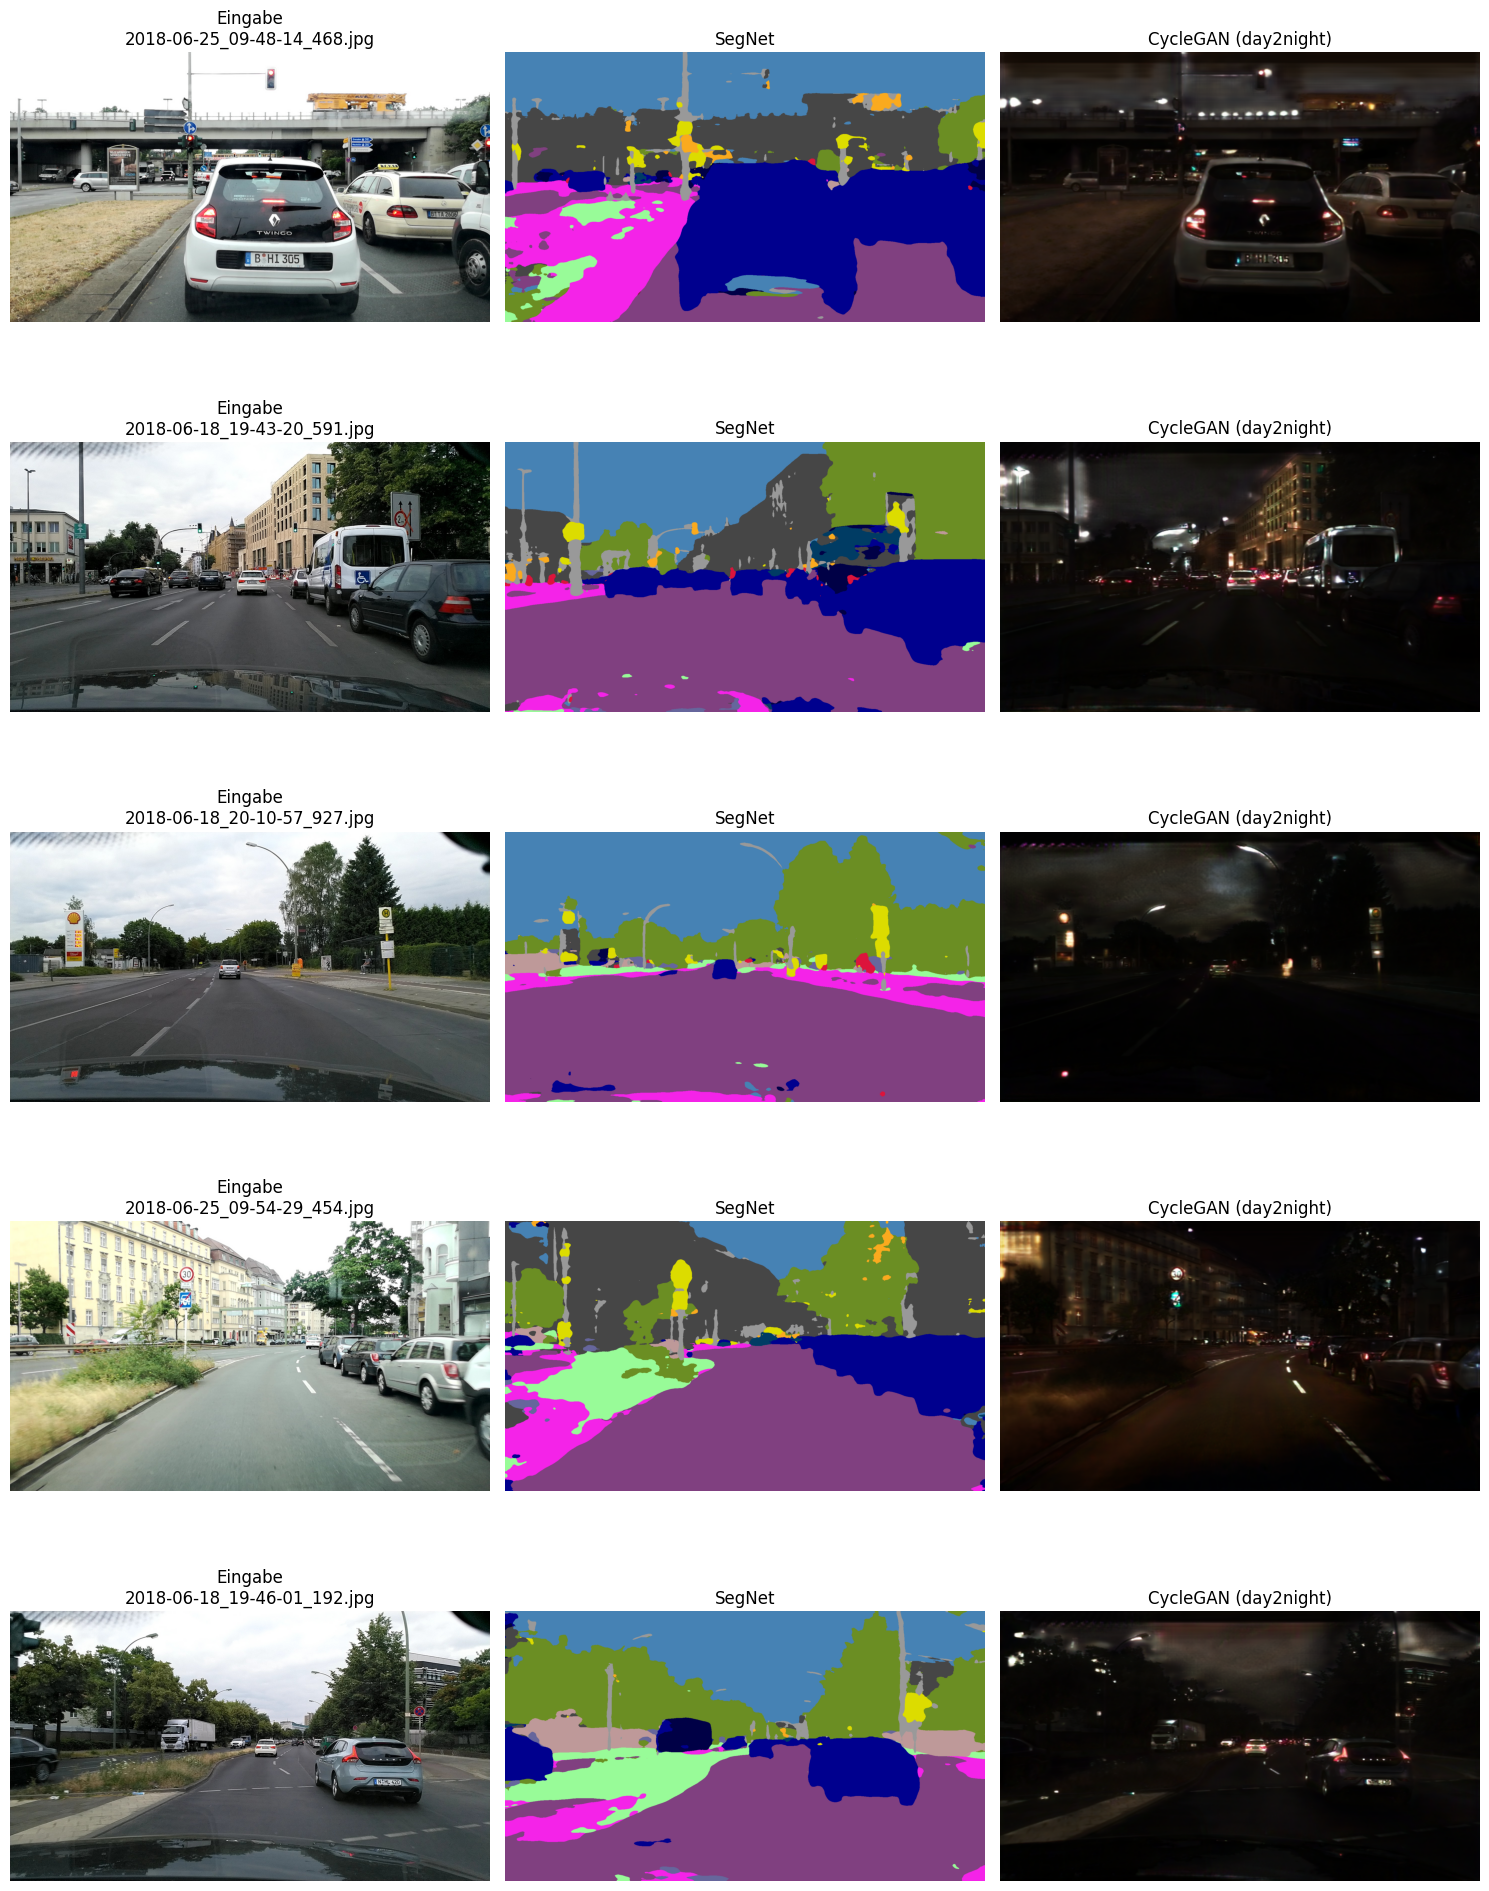

In [6]:
extensions = cyc_cfg.get("data", {}).get("extensions", ("jpg", "jpeg", "png", "bmp", "tif", "tiff"))
image_paths = gather_gan_paths(INPUT_DIR, extensions)
assert image_paths, f"Keine Bilder in {INPUT_DIR} gefunden."
sample_paths = random.sample(image_paths, min(NUM_SAMPLES, len(image_paths)))
print(f"Zeige {len(sample_paths)} zufällige Bilder aus {INPUT_DIR}")

def run_models(path: Path):
    img = Image.open(path).convert("RGB")
    mask_np = tensor_to_mask(seg_model, img, seg_transform, device, out_size=(img.height, img.width))
    mask_img = colorize_mask(mask_np, palette)
    with torch.inference_mode():
        inp = gan_transform(img).unsqueeze(0).to(device)
        out = generator(inp)
    gan_img = tensor_to_pil(out, brightness_gain=brightness_gain, output_gamma=output_gamma)
    gan_img = gan_img.resize(img.size, Image.BICUBIC)  # zurück auf Input-Seitenverhältnis
    return img, mask_img, gan_img

rows = len(sample_paths)
fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
if rows == 1:
    axes = axes.reshape(1, 3)

for row, img_path in enumerate(sample_paths):
    original, mask_img, gan_img = run_models(img_path)
    for col, (im, title) in enumerate((
        (original, "Eingabe"),
        (mask_img, "SegNet"),
        (gan_img, f"CycleGAN ({DIRECTION})"),
    )):
        ax = axes[row, col]
        if col == 0:
            ax.set_title(f"{title}\n{img_path.name}")
        else:
            ax.set_title(title)
        ax.imshow(im)
        ax.axis("off")

plt.tight_layout()
plt.show()
